# 05 - Hyperparameter Tuning

Tunes the XGBoost model selected in `04_model_comparison.ipynb` using 
`RandomizedSearchCV` with 5-fold cross-validation. Optimization targets 
macro F1 score rather than accuracy to address the class imbalance between 
Red and Blue win outcomes.

**Input:** `data/processed/cleaned_data.csv`  
**Output:** Best XGBoost hyperparameters and tuned model performance.

In [13]:
# Setup and imports 

import pandas as pd 
import sys
sys.path.append('../')
from src.preprocessing import build_preprocessor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

ufc_data = pd.read_csv("../data/processed/cleaned_data.csv")
ufc_data.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,Winner,title_bout,weight_class,...,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,Red_Win
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,Blue,False,Middleweight,...,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0,0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,Red,False,Women's Flyweight,...,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0,1
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,Red,False,Welterweight,...,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0,1
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,Blue,False,Featherweight,...,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0,0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,Blue,False,Middleweight,...,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0,0


In [7]:
# Split data into train and test sets

post_fight_cols = [
    'finish',              
    'finish_details',      
    'finish_round',        
    'finish_round_time',   
    'total_fight_time_secs' 
]

odds_cols = [
    'R_odds', 'B_odds', 'R_ev', 'B_ev',
    'r_dec_odds', 'b_dec_odds',
    'r_sub_odds', 'b_sub_odds',
    'r_ko_odds', 'b_ko_odds'
]

id_cols = ['R_fighter', 'B_fighter', 'date', 'Winner']
cols_to_remove = post_fight_cols + odds_cols + id_cols 

X = ufc_data.drop(columns=['Red_Win', 'Winner', 'date', 'R_fighter', 'B_fighter'] + cols_to_remove)
y = ufc_data['Red_Win']

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [8]:
# Define parameter grid for XGBoost
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__scale_pos_weight': [1, 2, 3]  
}

In [9]:
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', build_preprocessor(numeric_cols, categorical_cols)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

random_search = RandomizedSearchCV(
    pipeline_xgb,
    param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['no_of_rounds',
                                                                                'B_current_lose_streak',
                                                                                'B_current_win_streak',
                                                                                'B_draw',
                                                                                'B_avg_SIG_STR_landed',
                                                                                'B_avg_SIG_STR_pct',
                                                                                'B_avg_SUB_ATT',
                                                                                'B_avg_TD_landed',
                                                                                'B_av...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__scale_pos_weight': [1, 2, 3],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [10]:
# Inspect best parameters
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Best parameters: {'model__subsample': 0.8, 'model__scale_pos_weight': 1, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6}
Best CV score: 0.5820882417390468


Accuracy: 0.628
              precision    recall  f1-score   support

           0       0.58      0.39      0.47       598
           1       0.65      0.80      0.71       838

    accuracy                           0.63      1436
   macro avg       0.61      0.59      0.59      1436
weighted avg       0.62      0.63      0.61      1436



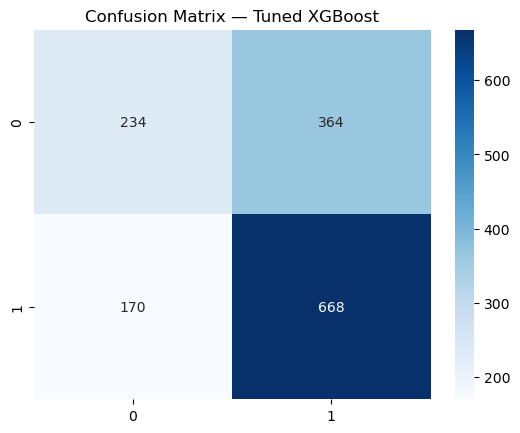

In [11]:
y_pred_tuned = random_search.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.3f}")
print(classification_report(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Tuned XGBoost')
plt.show()

## Tuning Results

**Best parameters found via RandomizedSearchCV (30 iterations, 5-fold CV):**
- `max_depth: 3` — shallow trees prevent overfitting on noisy fight data
- `learning_rate: 0.1` — moderate step size balances speed and accuracy
- `n_estimators: 200` — more trees improved over default 100
- `scale_pos_weight: 1` — class imbalance correction not beneficial here
- `subsample: 0.8`, `colsample_bytree: 0.6` — aggressive subsampling reduces overfitting

### Model Tuning Comparison Summary 

| Model | Accuracy | Class 0 Recall | Class 1 Recall | F1 (macro) |
|-------|----------|----------------|----------------|------------|
| XGBoost (default) | 0.596 | 0.43 | 0.71 | 0.57 |
| XGBoost (tuned) | 0.628 | 0.39 | 0.80 | 0.59 |

**Improvement over default XGBoost:**
- Accuracy: 0.596 → 0.628 (+0.032)
- Macro F1: 0.57 → 0.59 (+0.02)
- Class 0 recall dropped slightly (0.43 → 0.39) — model remains biased toward Red wins

In [14]:
# Save the final tuned model 

joblib.dump(random_search.best_estimator_, '../models/tuned_xgboost.pkl')
print("Model saved to models/tuned_xgboost.pkl")

Model saved to models/tuned_xgboost.pkl
